In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS
import linearmodels
from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.datasets import wage_panel
import statsmodels.api as sm
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
def hausman(fe, re):
    b_FE = fe.params
    b_RE = re.params

    common_coef = b_FE.index.intersection(b_RE.index)
    b_FE = b_FE[common_coef]
    b_RE = b_RE[common_coef]

    diff = b_FE - b_RE

    v_FE = fe.cov.loc[common_coef, common_coef]
    v_RE = re.cov.loc[common_coef, common_coef]
    v_diff = v_FE - v_RE

    stat = np.dot(np.dot(diff.T, np.linalg.inv(v_diff)), diff)
    df = diff.shape[0]
    pval = 1 - stats.chi2.cdf(stat, df)

    return pd.Series({"chi2": stat, "df": df, "p-value": pval})

In [ ]:
df=pd.read_csv('../../data/panel_eps.csv')
df.describe()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
count,9.684600e+04,96846.000000,96846.000000,96846.000000,96796.000000,92920.000000,80848.000000,96736.00000,96846.000000,78017.000000,...,0.0,0.0,0.0,0.0,96846.000000,70281.000000,80408.000000,80537.000000,80537.000000,80537.000000
mean,1.253178e+11,7.991213,3.493898,1673.399903,0.494979,7.905585,9.148959,2.62378,0.357082,0.741633,...,NaN,NaN,NaN,NaN,13.473432,131.131273,0.361096,0.213144,0.073084,0.074289
std,1.296642e+09,4.566324,1.727313,711.910128,0.499977,5.106440,3.678007,1.73293,0.479142,1.013718,...,NaN,NaN,NaN,NaN,10.354177,216.851544,0.480321,0.409531,0.260277,0.262242
min,1.245602e+11,2.000000,1.000000,20.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246212e+11,4.000000,2.000000,1982.000000,0.000000,3.000000,6.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,3.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247076e+11,6.000000,3.000000,1986.000000,0.000000,7.000000,9.000000,2.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248369e+11,12.000000,5.000000,1992.000000,1.000000,12.000000,13.000000,5.00000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,22.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,1.000000,19.000000,15.000000,5.00000,1.000000,8.000000,...,NaN,NaN,NaN,NaN,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.head()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN


## 1. Limpieza de Datos

(1) Renombramos algunas columnas para un manejo más sencillo

(2) No se considerarán los Fondos de Pensiones a los que pertenecen por lo que se eliminan

(3) Pasamos la edad de las personas al año de nacimiento

(4) Consideramos solo el primer valor del año de nacimiento (Tenía algunos errores, avanzaba el año de nacimiento según avanzaba el año de la encuesta)

(5) Crear una variable para saber si es mujer o no (No se si es necesario)

(6) Para corregir la respuesta de años de educación, se borraran las filas que no contengan valores en esa celda.

(7) Para corregir la región, consideraremos mantener la región con más frecuencia. Para los que no respondieron, indicaremos con "0" que pertenecen a alguna región

(8) Eliminamos las filas con valores faltantes (REVISAR ESTO, PODRÍA SOLO DEJARLAS SI NO OCUPO ESTA VARIABLES)

(9) Imputar valores de Children, sabiendo que el valor en la columna "Kids" es "0", lo que implica que no tienen niños.

(10) Supondremos que la gente que no respondió "exp" (años de experiencia laboral), entonces no tienen experiencia.

(11) Como "size" tiene 30% de datos, no usaremos la columna, por lo que la eliminamos

(12) Tiene solo el 50% de Datos (No se que hacer con esta)

(13) Imputamos valores de "wage", sabiendo que si su situación es "Cesante(2)" o "Inactivo(4)", entonces no tiene salario

(14) Imputamos valores de "hours", sabiendo que si su situación es "Cesante(2)" o "Inactivo(4)", entonces no tiene horario laboral

(15) Las variables "selfemp y publicemp", tienen aproximadamente la mitad de los datos e imputamos valores considerando que si su situación es 'desempleado' o 'inactivo' entonces no trabaja ni en el trabajo publico ni como independiente.

(16) Filtro el dF para quedarme solo con los valores menores a 120 en expectativa de vida (expectancy), considerando 120 como un numero más que razonable para la expectativa de vida

(17) Imputamos valores de "illnes", considerando el valor más frecuente por individuo en las distintas rondas

(18) Imputamos valores de "cronica", considerando el valor más frecuente por individuo en las distintas rondas

(19) Imputamos valores de "nocronica", considerando el valor más frecuente por individuo en las distintas rondas

(20) Imputamos valores de "mental", considerando el valor más frecuente por individuo en las distintas rondas

(21) Eliminamos los Nan de las variables "illness", "cronica", "nocronica", "mental", "wage" y "hours" para poder usarlas en las regresiones

(22) Hacemos las variables "time (time_survey)", "status" y "situation" dummies para incluirlas en las regresiones

(23) Indexamos las variables "ID" y "Time", para poder hacer las regresiones y ocupar el formato de panel

In [5]:
df=pd.read_csv('../../data/panel_eps.csv')

#(1)
df = df.rename(columns={
    'folio_n20':'ID'
})

#(2)
df = df.drop(['fondoa', 'fondob', 'fondoc', 'fondod', 'fondoe'], axis=1)

#(3)
#df.loc[df['edad'] < 100, 'edad'] = 2000 + df.loc[df['edad'] < 100, 'year'] - df.loc[df['edad'] < 100, 'edad'] 

#(4)
#df['edad'] = df.groupby('ID')['edad'].transform('first')

#(5)
df['mujer'] = 1 - df['hombre']

#(6)
df = df.dropna(subset=['edu'])

#(7)
df['region'] = df.groupby('ID')['region'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else 0
)

#(8)
df = df.dropna(subset=['status'])

#(9)
df.loc[(df['kids'] == 0) & (df['children'].isna()), 'children'] = 0

#(10)
df['exp'] = df['exp'].fillna(0)

#(11)
df = df.drop(['size'], axis=1)

#(12)
df.loc[(df['situation'] == 2) & (df['occupation'].isna()), 'occupation'] = 0
df.loc[(df['situation'] == 4) & (df['occupation'].isna()), 'occupation'] = 0

#(13)
df.loc[(df['situation'] == 2) & (df['wage'].isna()), 'wage'] = 0
df.loc[(df['situation'] == 4) & (df['wage'].isna()), 'wage'] = 0

#(14)
df.loc[(df['situation'] == 2) & (df['hours'].isna()), 'hours'] = 0
df.loc[(df['situation'] == 4) & (df['hours'].isna()), 'hours'] = 0

#(15)
df.loc[(df['situation'] == 2) & (df['selfemp'].isna()), 'selfemp'] = 0
df.loc[(df['situation'] == 4) & (df['selfemp'].isna()), 'selfemp'] = 0

df.loc[(df['situation'] == 2) & (df['publicemp'].isna()), 'publicemp'] = 0
df.loc[(df['situation'] == 4) & (df['publicemp'].isna()), 'publicemp'] = 0

#(16)
df = df[df['expectancy'] < 100]


#(17)
df['illness'] = df.groupby('ID')['illness'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.NaN
)

#(18)
df['cronica'] = df.groupby('ID')['cronica'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.NaN
)

#(19)
df['nocronica'] = df.groupby('ID')['nocronica'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.NaN
)

#(20)
df['mental'] = df.groupby('ID')['mental'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.NaN
)

#(21)
df = df.dropna(subset=['illness', 'cronica', 'nocronica', 'mental', 'wage', 'hours'])


#(22)
df['time_survey'] = df['time'].astype(object)
df['status'] = df['status'].astype(object)
df['situation'] = df['situation'].astype(object)
df = pd.get_dummies(df)

#(23)
df = df.set_index(["ID","time"])


FileNotFoundError: [Errno 2] No such file or directory: '../../data/panel_eps.csv'

In [ ]:
df.head(10)

year  edad  hombre   edu  region  kids  children  lmp  \
ID           time                                                          
124560204870 2        4    49     0.0   7.0     5.0     1       1.0    0   
             3        6    51     0.0   4.0     5.0     1       1.0    0   
             4        9    54     0.0   5.0     5.0     1       1.0    0   
             5       12    57     0.0   4.0     5.0     0       0.0    1   
124560205935 1        2  1982     0.0  15.0    13.0     1       4.0    0   
             2        4  1984     0.0  15.0    13.0     1       3.0    0   
124560210408 1        2  1982     0.0   4.0    13.0     1       1.0    1   
             2        4  1984     0.0   4.0    13.0     0       0.0    2   
             3        6  1986     0.0   3.0    13.0     0       0.0    2   
             5       12  1992     0.0   3.0    13.0     0       0.0    0   

                    exp  occupation  ...  status_4.0  status_5.0  situation_2  \
ID           time                    ...                                        
124560204870 2      0.0         0.0  ...       False       False        False   
             3      0.0         0.0  ...       False       False        False   
             4      0.0         0.0  ...       False       False        False   
             5      0.0         NaN  ...       False        True        False   
124560205935 1      6.0         0.0  ...       False       False        False   
             2      6.0         0.0  ...       False       False        False   
124560210408 1     22.0         7.0  ...       False       False        False   
             2     23.0         9.0  ...       False       False        False   
             3     26.0         9.0  ...       False       False        False   
             5     29.0         0.0  ...        True       False        False   

                   situation_3  situation_4  time_survey_1  time_survey_2  \
ID           time                                                           
124560204870 2           False         True          False           True   
             3           False         True          False          False   
             4           False         True          False          False   
             5            True        False          False          False   
124560205935 1           False         True           True          False   
             2           False         True          False           True   
124560210408 1            True        False           True          False   
             2            True        False          False           True   
             3            True        False          False          False   
             5           False         True          False          False   

                   time_survey_3  time_survey_4  time_survey_5  
ID           time                                               
124560204870 2             False          False          False  
             3              True          False          False  
             4             False           True          False  
             5             False          False           True  
124560205935 1             False          False          False  
             2             False          False          False  
124560210408 1             False          False          False  
             2             False          False          False  
             3              True          False          False  
             5             False          False           True  

[10 rows x 38 columns]

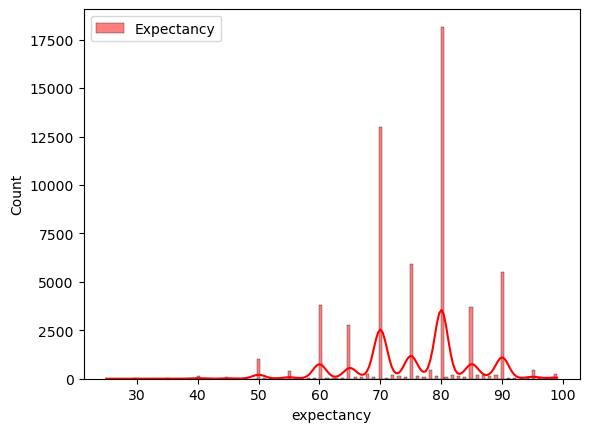

In [ ]:
sns.histplot(data=df['expectancy'], color="red", label="Expectancy", kde=True)

plt.legend() 
plt.show()

<Axes: >

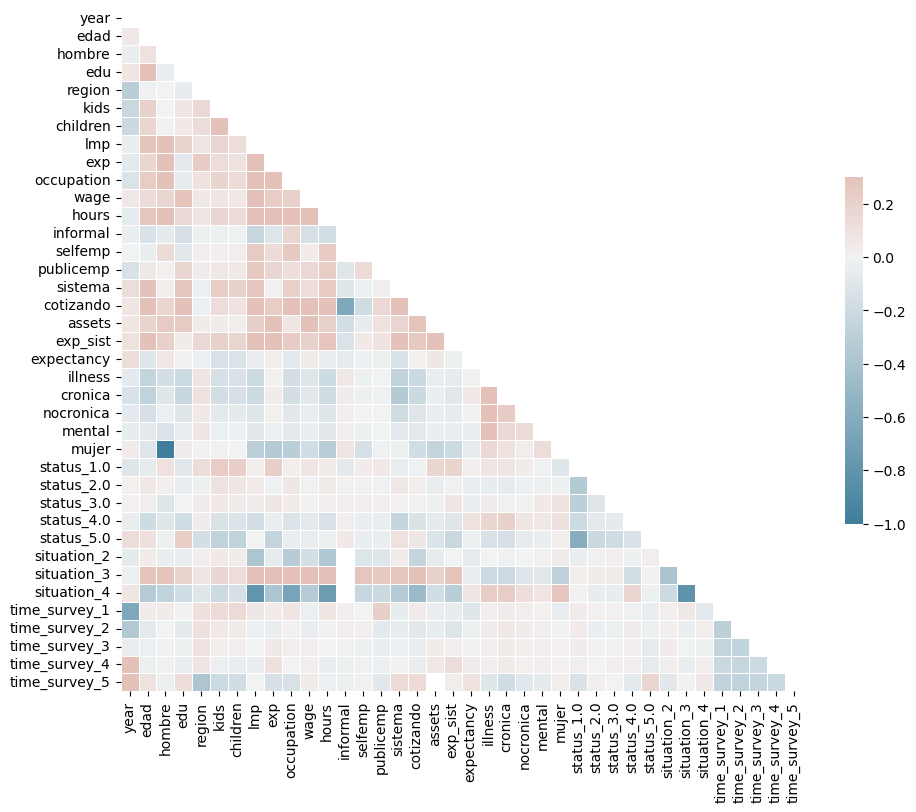

In [ ]:
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

## 2. Pooled OLS

In [ ]:
y=df['expectancy']
X=df[['edu', 'illness', 'cronica', 'mental', 'status_2.0','status_3.0', 'status_4.0', 'status_5.0', 'children', 'situation_3', 'situation_4', 'wage', 'hours', 'selfemp', 'publicemp', 'exp', 'exp_sist', 'time_survey_1', 'time_survey_2', 'time_survey_3', 'time_survey_4']]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0560
Estimator:                   PanelOLS   R-squared (Between):              0.0630
No. Observations:               58844   R-squared (Within):               0.0357
Date:                Tue, May 20 2025   R-squared (Overall):              0.0560
Time:                        21:31:01   Log-likelihood                -2.146e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      166.01
Entities:                       23117   P-value                           0.0000
Avg Obs:                       2.5455   Distribution:                F(21,58822)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             166.01
                            

R: Podemos observar que todas las variables son significativas (valor-p < 0.05) excepto "hours" y "publicemp". Luego, vemos que el modelo explica muy poco de la Data (R^2 = 5,6%). Además, la interpretación que podemos darle a los parámetros calculados para cada variable es,

1. Cada un año de educación más, se espera que aporte a la expectativa de vida positivamente (+) en 0,0607 años. 
2. Si hay una enfermedad (cualquiera sea), se espera que aporte a la expectativa de vida negativamente (-) en 1,4175 años.
3. Si hay una enfermedad crónica, se espera que aporte a la expectativa de vida positivamente (+) en 1,8265 años. (Lo cual no hace mucho sentido)
4. Si hay una enfermedad mental, se espera que aporte a la expectativa de vida negativamente (-) en 1,9043 años.
5. Si la persona convive, se espera que aporte a la expectativa de vida negativamente (-) en 1,0735 años.
6. Si la persona es divorciada, se espera que aporte a la expectativa de vida negativamente 1,2824 años.
7. Si la persona es viuda, se espera que aporte a la expectativa de vida positivamente en 3,2865 años.
8. Si la persona es soltera, se espera que aporte a la expectativa de vida negativamente 1,2935 años.
9. Por cada niño menor o igual a 18 años, se espera que aporte a la expectativa de vida negativamente en 0,9080 años.
10. Si la persona está trabajando, se espera que aporte a la expectativa de vida positivamente en 0,9647 años.
11. Si la persona está inactiva, se espera que aporte a la expectativa de vida positivamente en 2,1478 años.
12. Por cada 100.000 pesos de sueldo, se espera que aporte a la expectativa de vida positivamente en 0,1279 años.
13. Por cada hora trabajada semanalmente, se espera que aporte a la expectativa de vida negativamente en 0,0052 años.
14. Si la persona trabaja independiente, se espera que aporte a la expectativa de vida negativamente en 0,5542 años.
15. Si la persona trabaja en un servicio público, se espera que aporte a la expectativa de vida negativamente en 0,1671 años.
16. Por cada año de experiencia, se espera que aporte a la expectativa de vida positivamente en 0,0881 años.
17. Por cada año en sistema de pensiones, se espera que aporte a la expectativa de vida negativamente en 0,0509 años.
18. En el primer año los efectos externos afectaron negativamente a la expectativa de vida en 3,4286 años.
19. En el segundo año los efectos externos afectaron negativamente a la expectativa de vida en 2,2495 años.
20. En el tercer año los efectos externos afectaron negativamente a la expectativa de vida en 1,8977 años.
21. En el cuarto año los efectos externos afectaron negativamente a la expectativa de vida en 1,4796 años.

## 3. Fixed Effects 

In [ ]:
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
fe=model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0495
Estimator:                   PanelOLS   R-squared (Between):             -0.0101
No. Observations:               58844   R-squared (Within):               0.0495
Date:                Tue, May 20 2025   R-squared (Overall):              0.0138
Time:                        21:31:03   Log-likelihood                -1.887e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      103.28
Entities:                       23117   P-value                           0.0000
Avg Obs:                       2.5455   Distribution:                F(18,35709)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             81.925
                            

R: Podemos observar que solo las variables "wage", "exp_sist", "time_survey_1", "time_survey_2", "time_survey_3" y "time_survey_4" son significativas (valor-p < 0.05), además el modelo explica muy poco de la Data (R^2 = 4,95%). Por otro lado, se puede ver que hay variables que no cambiaban en el tiempo por lo que al estimar la regresión fueron absorvidas. 

La interpretación que podemos darle a los parámetros calculados para cada variable significativa es,

1. Cada un año de educación más, se espera que aporte a la expectativa de vida negativamente (-) en 0,0142 años. 
2. Si la persona convive, se espera que aporte a la expectativa de vida negativamente (-) en 0,3415 años.
3. Si la persona es divorciada, se espera que aporte a la expectativa de vida negativamente (-) 0,4691 años.
4. Si la persona es viuda, se espera que aporte a la expectativa de vida positivamente en 0,0586 años.
5. Si la persona es soltera, se espera que aporte a la expectativa de vida negativamente 0,0539 años.
6. Por cada niño menor o igual a 18 años, se espera que aporte a la expectativa de vida positivamente en 0,0792 años.
7. Si la persona está trabajando, se espera que aporte a la expectativa de vida positivamente en 0,1479 años.
8. Si la persona está inactiva, se espera que aporte a la expectativa de vida negativamente en 0,0458 años.
9. Por cada 100.000 pesos de sueldo, se espera que aporte a la expectativa de vida positivamente en 0,03158 años.
10. Por cada hora trabajada semanalmente, se espera que aporte a la expectativa de vida positivamente en 0,0019 años.
11. Si la persona trabaja independiente, se espera que aporte a la expectativa de vida negativamente en 0,1301 años.
12. Si la persona trabaja en un servicio público, se espera que aporte a la expectativa de vida negativamente en 0,2006 años.
13. Por cada año de experiencia, se espera que aporte a la expectativa de vida positivamente en 0,0523 años.
14. Por cada año en sistema de pensiones, se espera que aporte a la expectativa de vida negativamente en 0,1078 años.
15. En el primer año los efectos externos afectaron negativamente a la expectativa de vida en 5,8861 años.
16. En el segundo año los efectos externos afectaron negativamente a la expectativa de vida en 4,2607 años.
17. En el tercer año los efectos externos afectaron negativamente a la expectativa de vida en 3,5170 años.
18. En el cuarto año los efectos externos afectaron negativamente a la expectativa de vida en 2,5057 años.

## 4. Random Effects

In [ ]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4645
Estimator:              RandomEffects   R-squared (Between):              0.0594
No. Observations:               58844   R-squared (Within):               0.0415
Date:                Tue, May 20 2025   R-squared (Overall):              0.0543
Time:                        21:31:05   Log-likelihood                -2.035e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2429.9
Entities:                       23117   P-value                           0.0000
Avg Obs:                       2.5455   Distribution:                F(21,58822)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             144.16
                            

R: Podemos ver que este modelo explica mucho mejor que los anteriores, con un R^2 de 46,45%. Además, el modelo en general es significativo y solo tiene dos variables no significativa que es "hours" y "publicemp" (valor-p > 0.05). Luego, el modelo entrega la siguiente interpretación por parámetro estimado y las variables:

1. Cada un año de educación más, se espera que aporte a la expectativa de vida positivamente (+) en 0,0421 años. 
2. Si hay una enfermedad (cualquiera sea), se espera que aporte a la expectativa de vida negativamente (-) en 1,4612 años.
3. Si hay una enfermedad crónica, se espera que aporte a la expectativa de vida positivamente (+) en 2,2873 años. (Lo cual no hace mucho sentido)
4. Si hay una enfermedad mental, se espera que aporte a la expectativa de vida negativamente (-) en 1,7408 años.
5. Si la persona convive, se espera que aporte a la expectativa de vida negativamente (-) en 1,0353 años.
6. Si la persona es divorciada, se espera que aporte a la expectativa de vida negativamente 1,1179 años.
7. Si la persona es viuda, se espera que aporte a la expectativa de vida positivamente en 2,9214 años.
8. Si la persona es soltera, se espera que aporte a la expectativa de vida negativamente 1,1710 años.
9. Por cada niño menor o igual a 18 años, se espera que aporte a la expectativa de vida negativamente en 0,7743 años.
10. Si la persona está trabajando, se espera que aporte a la expectativa de vida positivamente en 0,5887 años.
11. Si la persona está inactiva, se espera que aporte a la expectativa de vida positivamente en 1,3316 años.
12. Por cada 100.000 pesos de sueldo, se espera que aporte a la expectativa de vida positivamente en 0,09463 años.
13. Por cada hora trabajada semanalmente, se espera que aporte a la expectativa de vida negativamente en 0,0038 años.
14. Si la persona trabaja independiente, se espera que aporte a la expectativa de vida negativamente en 0,3470 años.
15. Si la persona trabaja en un servicio público, se espera que aporte a la expectativa de vida negativamente en 0,1297 años.
16. Por cada año de experiencia, se espera que aporte a la expectativa de vida positivamente en 0,0819 años.
17. Por cada año en sistema de pensiones, se espera que aporte a la expectativa de vida negativamente en 0,0519 años.
18. En el primer año los efectos externos afectaron negativamente a la expectativa de vida en 3,9872 años.
19. En el segundo año los efectos externos afectaron negativamente a la expectativa de vida en 2,6794 años.
20. En el tercer año los efectos externos afectaron negativamente a la expectativa de vida en 2,2437 años.
21. En el cuarto año los efectos externos afectaron negativamente a la expectativa de vida en 1,7130 años.

## 5. Comparación de Modelos

In [ ]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 58844             58844          58844
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0495            0.4645         0.0560
R-Squared (Within)              0.0495            0.0415         0.0357
R-Squared (Between)            -0.0101            0.0594         0.0630
R-Squared (Overall)             0.0138            0.0543         0.0560
F-statistic                     103.28            2429.9         166.01
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

### Test de Hausman

In [ ]:
#Test de Hausman para comparación entre Modelos FE y RE.

#H0 : No hay correlación entre los efectos no observados y las variables explicativas. (Random Effects Mejor)
#HA : Hay correlación entre los efectos nos observados y las variables explicativas. (Fixed Effects Mejor)

import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
    common_vars = fe.params.index.intersection(re.params.index)

    fe_params = fe.params.loc[common_vars]
    re_params = re.params.loc[common_vars]

    fe_cov = fe.cov.loc[common_vars, common_vars]
    re_cov = re.cov.loc[common_vars, common_vars]

    diff = fe_params - re_params
    psi = fe_cov - re_cov

    dof = len(diff)
    W = diff.dot(la.inv(psi)).dot(diff)
    pval = stats.chi2.sf(W, dof)
    return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 238.54715163601082, df = 19, p-value = 6.3969097679581825e-40


### Robustez de los Parámetros (Considerando su magnitud, significancia y std)

In [ ]:
fe_res = fe.params
re_res = re.params
mco_res = mco.params

fe_se = fe.std_errors
re_se = re.std_errors
mco_se = mco.std_errors

# Comparar en un DataFrame
comparison = pd.DataFrame({
    "Coef_FE": fe_res,
    "SE_FE": fe_se,
    "Coef_RE": re_res,
    "SE_RE": re_se,
    "Coef_MCO": mco_res,
    "SE_MCO": mco_se,
})
print(comparison)

                    Coef_FE         SE_FE       Coef_RE         SE_RE  \
children       7.917336e-02  1.014202e-01 -7.742570e-01  5.174892e-02   
const          7.987349e+01  7.824833e-01  7.765946e+01  2.108138e-01   
cronica                 NaN           NaN  2.287283e+00  2.040696e-01   
edu           -1.422498e-02  2.305716e-02  4.207059e-02  9.676113e-03   
exp            5.226210e-02  3.309546e-02  8.191032e-02  6.344162e-03   
exp_sist      -1.077613e-01  3.915166e-02 -5.189121e-02  6.138319e-03   
hours          1.938745e-03  5.001717e-03 -3.819660e-03  3.784419e-03   
illness                 NaN           NaN -1.461175e+00  1.825186e-01   
mental                  NaN           NaN -1.740766e+00  2.829659e-01   
publicemp     -2.006178e-01  1.936455e-01 -1.296750e-01  1.394394e-01   
selfemp       -1.301301e-01  1.996047e-01 -3.470477e-01  1.345200e-01   
situation_3    1.478515e-01  2.873142e-01  5.886943e-01  2.234763e-01   
situation_4   -4.578445e-02  1.972144e-01  1.331643

R: Se puede ver claramente, que el modelo de Random Effects explica más de la data que los otros dos modelos y tiene ciertas ventajas respecto a los otros, las que se muestran a continuación:

1. Pooled OLS, no es la mejor para trabajar con datos de panel porque ignora que los datos tienen repetición en el tiempo o que hay más de un dato de una persona o un individuo en diferentes tiempos, por lo que ignora los efectos individuales. Junto con lo anterior, si las diferencias están correlacionadas con las covariables, puede haber un sesgo de omisión. (REVISAR BIEN)

2. Sobre Fixed Effects (Efectos Fijos), si considera los datos en el tiempo, pero estima el efecto usando solo la variación dentro del individuo en el tiempo. El problema de esto, es que pueden haber variables que no cambien significativamente en el tiempo y el modelo las elimina, por lo que no puede estimar los efectos de estas variables y puede afectar significativamente a la regresión.

3. Random Effects, en este caso se podría decir que es la mejor opción debido a que, estima el efecto de las variaciones del individuo en el tiempo y además, estima las variables que no cambian en el tiempo y lo modela como parte del error. Además, considera el efecto del individuo y también entre individuos, lo que lo hace estadísticamente más eficiente y puede explicar mucho más que los otros modelos. 

Ahora, realizando el Test de Hausman, para ver que modelo es más adecuado entre Fixed Effects y Random Effects, podemos ver que el Valor-P es menor a 0.05 (6,397*10^-40) por lo que rechazamos la hipótesis nula, lo que indica que hay correlación entre los efectos no observados y las variables explicativas, por lo cual se puede concluir que el modelo de Fixed Effects es más adecuado para proyectar el efecto de las variables independientes respecto a la expectativa de vida.

Por otro lado, podemos observar variables robustas, considerando que las variables son robustas cuando son significativas, tienen el mismo signo y parecida magnitud relativa en todos los modelos. Siguiendo esto, podemos observar que las variables robustas son:

- exp_sist
- wage
- time_survey_1
- time_survey_2
- time_survey_3
- time_survey_4

Como hay variables que no se encuentran en Fixed Effects no las incluimos, pero pueden ser robustas (potencialmente robustas) comparándolas entre RE y MCO:

- cronica
- illness
- mental

## 6. Correlated Random Effects 

In [ ]:
X = df.drop(
    ['expectancy', 'status_1.0', 'mujer'], 
    axis=1, inplace=False
)
Xm = X.groupby(by = 'ID').transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]
Xc = pd.merge(df, Xm, left_index=True, right_index=True)
Y = Xc['expectancy']
X = Xc[['edu', 'illness', 'cronica', 'mental', 'status_2.0','status_3.0', 'status_4.0', 'status_5.0', 'children', 'situation_3', 'situation_4', 'wage', 'hours', 'selfemp', 'publicemp', 'exp', 'exp_sist', 'time_survey_1', 'time_survey_2', 'time_survey_3', 'time_survey_4', 'mchildren', 'mwage', 'mhours', 'medu', 'mexp', 'mexp_sist']]
X=sm.add_constant(X)
model=lmp.RandomEffects(y,X)
cre=model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4663
Estimator:              RandomEffects   R-squared (Between):              0.0621
No. Observations:               58844   R-squared (Within):               0.0445
Date:                Tue, May 20 2025   R-squared (Overall):              0.0578
Time:                        21:31:07   Log-likelihood                -2.034e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1903.3
Entities:                       23117   P-value                           0.0000
Avg Obs:                       2.5455   Distribution:                F(27,58816)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             118.10
                            

R: Podemos ver que este modelo explica un R^2 de 46,63%. Además, el modelo en general es significativo y solo tiene seis variables no significativa que son "edu", "children", "wage", "hours", "publicemp" y "mexp" (valor-p > 0.05). Luego, el modelo entrega la siguiente interpretación por parámetro estimado y las variables:

1. Cada un año de educación más, se espera que aporte a la expectativa de vida negativamente (-) en 0,0114 años. 
2. Si hay una enfermedad (cualquiera sea), se espera que aporte a la expectativa de vida negativamente (-) en 1,4477 años.
3. Si hay una enfermedad crónica, se espera que aporte a la expectativa de vida positivamente (+) en 2,0008 años. (Lo cual no hace mucho sentido)
4. Si hay una enfermedad mental, se espera que aporte a la expectativa de vida negativamente (-) en 1,8335 años.
5. Si la persona convive, se espera que aporte a la expectativa de vida negativamente (-) en 0,9926 años.
6. Si la persona es divorciada, se espera que aporte a la expectativa de vida negativamente 1,1064 años.
7. Si la persona es viuda, se espera que aporte a la expectativa de vida positivamente en 2,7538 años.
8. Si la persona es soltera, se espera que aporte a la expectativa de vida negativamente 1,2246 años.
9. Por cada niño menor o igual a 18 años, se espera que aporte a la expectativa de vida negativamente en 0,0385 años.
10. Si la persona está trabajando, se espera que aporte a la expectativa de vida positivamente en 0,513 años.
11. Si la persona está inactiva, se espera que aporte a la expectativa de vida positivamente en 1,115 años.
12. Por cada 100.000 pesos de sueldo, se espera que aporte a la expectativa de vida positivamente en 0,0316 años.
13. Por cada hora trabajada semanalmente, se espera que aporte a la expectativa de vida positivamente en 0,0061 años.
14. Si la persona trabaja independiente, se espera que aporte a la expectativa de vida negativamente en 0,3573 años.
15. Si la persona trabaja en un servicio público, se espera que aporte a la expectativa de vida negativamente en 0,2158 años.
16. Por cada año de experiencia, se espera que aporte a la expectativa de vida positivamente en 0,1095 años.
17. Por cada año en sistema de pensiones, se espera que aporte a la expectativa de vida positivamente en 0,1095 años.
18. En el primer año los efectos externos afectaron negativamente a la expectativa de vida en 3,0304 años.
19. En el segundo año los efectos externos afectaron negativamente a la expectativa de vida en 2,0106 años.
20. En el tercer año los efectos externos afectaron negativamente a la expectativa de vida en 1,7496 años.
21. En el cuarto año los efectos externos afectaron negativamente a la expectativa de vida en 1,4727 años.
22. En promedio, si se tiene más hijos, se espera que aporte negativamente a la expectativa de vida en 1,0438 años.
23. En promedio, por cada 100.000 pesos más de salario, se espera que aporte positivamente a la expectativa de vida en 0,1489 años.
24. En promedio, por cada hora trabajada a la semana, se espera que aporte negativamente a la expectativa de vida en 0,025 años.
24. En promedio, por cada año más de educación, se espera que aporte positivamente a la expectativa de vida en 0,0651 años.
25. En promedio, por cada año de experiencia, se espera que aporte negativamente a la expectativa de vida en 0,0291 años.
26. En promedio, por cada año en el sistema de pensiones, se espera que aporte negativamente a la expectativa de vida en 0,1619 años.

Además, podemos ver que 5 de 6 de nuestras variables no observadas son significativas, lo que sugiere que no hay correlación entre los efectos no observados y los observados, por lo que no se cumple uno de los supuestos para RE y se prefiere el modelo CRE. 

## 7. Predecir la Distribución de los Datos no Observados

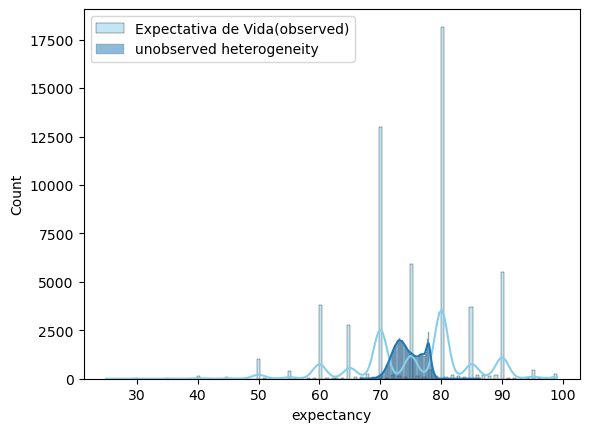

In [ ]:
Xpred = X
Xpred['edu']=0
Xpred['illness']=0
Xpred['cronica']=0
Xpred['mental']=0
Xpred['status_2.0']=0
Xpred['status_3.0']=0
Xpred['status_4.0']=0
Xpred['status_5.0']=0
Xpred['children']=0
Xpred['situation_3']=0
Xpred['situation_4']=0
Xpred['wage']=0
Xpred['hours']=0
Xpred['selfemp']=0
Xpred['publicemp']=0
Xpred['exp']=0
Xpred['exp_sist']=0
Xpred['time_survey_1']=0
Xpred['time_survey_2']=0
Xpred['time_survey_3']=0
Xpred['time_survey_4']=0
yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="Expectativa de Vida(observed)", kde=True)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True)

plt.legend() 
plt.show()

R: Se puede ver que lo observado tiene su mayor "pick" entre 80 años, mientras que lo no observado lo tiene entre 70-80 años. Además, se puede apreciar que lo no observado tiene una forma más clara que lo observado, lo que sugiere que si está aportando a explicar el modelo. 

## 8. Comparación de Modelos y Conclusiones

In [ ]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 58844             58844             58844
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0495            0.4645            0.4663
R-Squared (Within)              0.0495            0.0415            0.0445
R-Squared (Between)            -0.0101            0.0594            0.0621
R-Squared (Overall)             0.0138            0.0543            0.0578
F-statistic                     103.28            2429.9            1903.3
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

R: Se puede ver que tanto Random Effects como Correlated Random Effects logran explicar muy bien los datos, superando ampliamente al modelo de Fixed Effects, que queda detrás al no aprovechar la información entre individuos. Además, todos los modelos resultan estadísticamente significativos en conjunto, pero hay algunos puntos importantes:

Random Effects vs. Fixed Effects:
- RE aprovecha tanto la variación entre individuos como entre el individuo y sus respuestas en el tiempo, mientras que FE sólo utiliza la variación propia del individuo, lo cual limita la capacidad de proyección del modelo cuando las covariables presentan poca variación temporal.

- Esa mayor capacidad de explicar de RE se refleja en un R^2 mucho mayor que el de FE.

Correlated Random Effects vs. Random Effects:
- Aunque el R^2 global de RE y CRE son muy parecido, el modelo CRE incorpora explícitamente la heterogeneidad no observada (mediante los promedios individuales de las covariables) corrigiendo cualquier sesgo si estos efectos fuesen correlacionados con las variables explicativas.

Por estas razones, podemos concluir que el mejor modelo en este caso es CRE.

## 9. Instrumentos (No se si está bien la idea pero es un Intento c: )

### Modelo Agrupado (2SLS) (No importa el Tiempo)

In [ ]:
import linearmodels.iv as iv

iv_model = iv.IV2SLS.from_formula(
    'expectancy ~ illness + cronica + mental + status_2.0 + status_3.0 + status_4.0 + status_5.0 + children + situation_3 + situation_4 + wage + hours + selfemp + publicemp + exp + exp_sist + time_survey_1 + time_survey_2 + time_survey_3 + time_survey_4 + [edu ~ medu]',
    data=Xc
).fit(cov_type='robust')

print(iv_model.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:             expectancy   R-squared:                      0.9473
Estimator:                    IV-2SLS   Adj. R-squared:                 0.9473
No. Observations:               58844   F-statistic:                 1.487e+06
Date:                Tue, May 20 2025   P-value (F-stat)                0.0000
Time:                        21:31:11   Distribution:                 chi2(21)
Cov. Estimator:                robust                                         
                                                                              
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
illness           5.2850     0.2678     19.737     0.0000      4.7601      5.8098
cronica           0.6832     0.3066     

### Modelo de Panel Usando Efectos Fijos

No estoy seguro si está bien el modelo, lo pillé estudiando 

In [ ]:
from linearmodels.iv import IVGMM

iv_panel = IVGMM.from_formula(
    'expectancy ~ illness + cronica + mental + status_2.0 + status_3.0 + status_4.0 + status_5.0 + children + situation_3 + situation_4 + wage + hours + selfemp + publicemp + exp + exp_sist + time_survey_1 + time_survey_2 + time_survey_3 + time_survey_4 + [edu ~ medu]',
    data=Xc
)
iv_panel.fit(cov_type='robust')


IV-GMM Estimation Summary                           
==============================================================================
Dep. Variable:             expectancy   R-squared:                      0.9473
Estimator:                     IV-GMM   Adj. R-squared:                 0.9473
No. Observations:               58844   F-statistic:                 1.487e+06
Date:                Tue, May 20 2025   P-value (F-stat)                0.0000
Time:                        21:31:14   Distribution:                 chi2(21)
Cov. Estimator:                robust                                         
                                                                              
                               Parameter Estimates                               
=================================================================================
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
illness           5.2850     0.2678     19.737     0.0000      4.7601      5.8098
cronica           0.6832     0.3066     2.2286     0.0258      0.0824      1.2841
mental           -4.2372     0.4142    -10.229     0.0000     -5.0491     -3.4253
status_2.0        9.2361     0.2389     38.657     0.0000      8.7678      9.7044
status_3.0        6.2838     0.2615     24.031     0.0000      5.7713      6.7964
status_4.0        12.701     0.3305     38.429     0.0000      12.053      13.349
status_5.0        11.748     0.1934     60.737     0.0000      11.369      12.127
children          0.9952     0.0780     12.764     0.0000      0.8424      1.1480
situation_3       33.819     0.4057     83.354     0.0000      33.024      34.614
situation_4       39.785     0.2701     147.29     0.0000      39.256      40.315
wage          -2.435e-06  3.277e-07    -7.4306     0.0000  -3.077e-06  -1.793e-06
hours            -0.0593     0.0062    -9.5463     0.0000     -0.0715     -0.0471
selfemp           3.6507     0.2153     16.954     0.0000      3.2286      4.0727
publicemp        -5.9785     0.2223    -26.899     0.0000     -6.4142     -5.5429
exp               0.3154     0.0106     29.754     0.0000      0.2946      0.3362
exp_sist          0.5032     0.0099     50.859     0.0000      0.4838      0.5226
time_survey_1     16.577     0.2408     68.832     0.0000      16.105      17.049
time_survey_2     18.032     0.2337     77.177     0.0000      17.574      18.490
time_survey_3     17.312     0.2414     71.715     0.0000      16.838      17.785
time_survey_4     16.355     0.2500     65.419     0.0000      15.865      16.845
edu               1.3447     0.0167     80.416     0.0000      1.3119      1.3775
=================================================================================

Endogenous: edu
Instruments: medu
GMM Covariance
Debiased: False
Robust (Heteroskedastic)
IVGMMResults, id: 0x13a314810

R: Podemos ver que se mejoran los modelos, tanto en la significancia como en la explicación del modelo (mayor R^2)